In [12]:
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import simulation_cpu  as sim
import scipy.special as scp
import analyze_tool as an


Conductvity 
- connection betwin S to power/pulse width / dt(time_cut) , as in void .
- vector pointing return and transmision: - match to theory
                                          - end material effcts(?) - hard to conclude
- penetration depth 



In [5]:


lamda = 8e-7 
time_cycal= lamda/sim.c
fea = np.pi/2


time_cut = 100
dt = time_cycal/time_cut
dz = 2*sim.c *dt


eps_r = [6]
sigma = [2000]
ms0 = np.array([0, 0, 1]).reshape((1,3))
alpha =np.array([0.0001])
close_system = False
    

pulse_width = 4*time_cycal
power_in = 4



eps_r_comp = eps_r[0] - 1j * sigma[0] *lamda * sim.miu * sim.c /(2*np.pi)
n = eps_r_comp ** 0.5




len_matiral = int(8*pulse_width/dt/abs(n))*dz
z1 = int(3*pulse_width/dt) +3
z2 = z1 + int(len_matiral/dz)
z_list = [z1, z2] 
lenz= z2 + time_cut//2


pik_enter_step = 4*int(pulse_width/dt)
void_steps = 2*z1
matiral_steps = int(2* abs(n)* (z2 - z1))
exit_steps = time_cut

simulation_time = 2*(pik_enter_step + void_steps + matiral_steps + exit_steps)


t1 = pik_enter_step + void_steps
t2 = t1 + void_steps
t3 = t2 + 2*matiral_steps
t2_5 = (t2+ t3)//2


save_location = np.arange(z1- 1,z2+1)
save_location[0] = 4
save_location[-1] = lenz- 6
save_time = []




theoretical_reflectivity = (abs(( 1- n) /(1 + n))) ** 2
theoretical_transmision = 1 - theoretical_reflectivity
theoretical_penetration_depth_e = - 1/ (2* np.pi/ lamda * np.imag(n))  # power of the field decays to 1/e of its surface value.
theoretical_penetration_depth_p = 0.5 * theoretical_penetration_depth_e   # power decays to 1/e of its surface value.



Quick script to plot vector pointing in 3 important locations (Pulse enter, z1, end of simulation)

In [4]:
time_res, spece_res = sim.simulation(z_list, eps_r , sigma, alpha, ms0,
        power_in, fea , pulse_width,
        save_location, save_time, False,
        dt, simulation_time, lamda )

E_real= sim.heta*spece_res[1]
H = spece_res[0]
S = np.cross(np.real(E_real),np.real(H))

S_in_enter_point = S[:,0,2]
S_in_z1 = S[:,1,2]
S_in_out = S[:,-1,2] 
time = np.arange(0, simulation_time) *dt




S_send_to_void = sum(S_in_enter_point[:t1])*dt
S_first_return_to_void = sum(S_in_enter_point[t1:t2_5])*dt
S_first_enter_to_matirial = sum(S_in_z1[:t2])*dt


transmition = S_first_enter_to_matirial/ S_send_to_void
Return = S_first_return_to_void/ S_send_to_void


Transmition at z1 - 0.8220937395561729, expected : 0.8233909225864339
Return at z1 - -0.17937475207531545, expected : 0.17660907741356616
energy sent = 4.015483207443887 sum of aftar return : 4.0213799109304
energy compare -0.001474175871628347


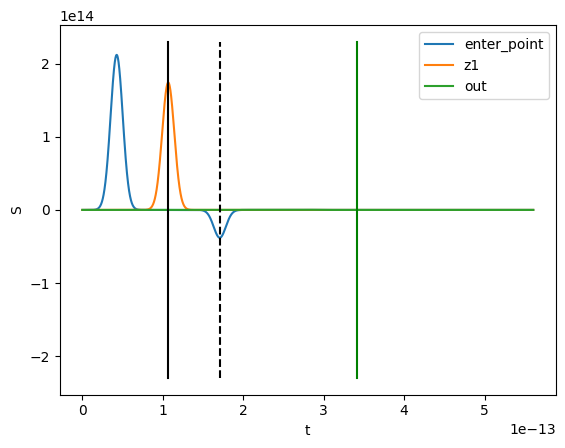

In [4]:


v = np.ones(2)
v_1 = np.array([-1, 1])
plt.plot(time, S_in_enter_point)

plt.plot(time, S_in_z1)
plt.plot(time, S_in_out)
plt.plot(dt*t1*v, 2.3e14*v_1, "k")
plt.plot(dt*t2*v, 2.3e14*v_1, "k--")
plt.plot(dt*t2_5*v, 2.3e14*v_1, "g")

# plt.plot([secnd_retuen_time*dt, secnd_retuen_time*dt], [2.7e14, -0.1e14], "k")
plt.legend(["enter_point" , "z1", "out"])
plt.ylabel("S")
plt.xlabel("t")
# for i, ind in enumerate(save_location):
print(f"Transmition at z1 - {transmition}, expected : {theoretical_transmision}")
# print(f"Transmition at z2 - {transmition_z2}, expected : {theoretical_transmision_power_z2}")
print(f"Return at z1 - {Return}, expected : {theoretical_reflectivity}")
# print(f"Return at z2 - {return_z2}, expected : {1 - theoretical_transmision_power_z2}")
print(f"energy sent = {S_send_to_void } sum of aftar return : { S_first_enter_to_matirial- S_first_return_to_void }")
print(f"energy compare {(S_send_to_void  - (S_first_enter_to_matirial- S_first_return_to_void))/power_in }")

penetration depth : 3.216e-06, expected : 3.251055125249178e-06


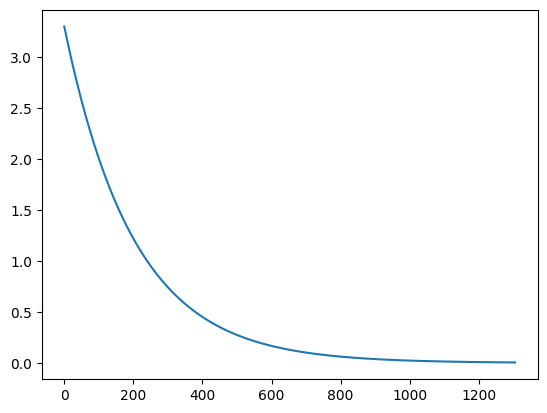

In [5]:
S_depletion = S[:,1:-1,2]

P_depletion = np.sum(S_depletion,0)* dt
target = max(P_depletion)/np.e
closest_index = np.argmin(np.abs(P_depletion - target)) 
penetration_depth = closest_index * dz
plt.plot(P_depletion)
print(f"penetration depth : {penetration_depth}, expected : {theoretical_penetration_depth_p}")

check1
 - power in effact on S

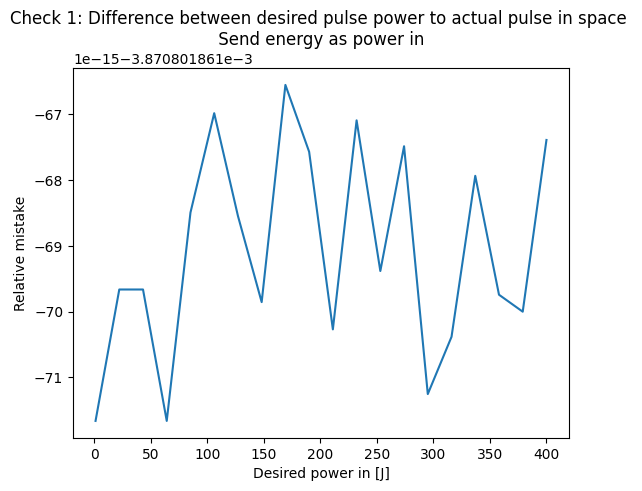

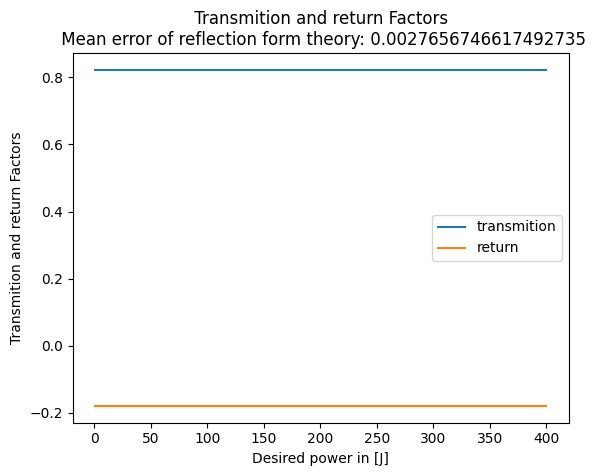

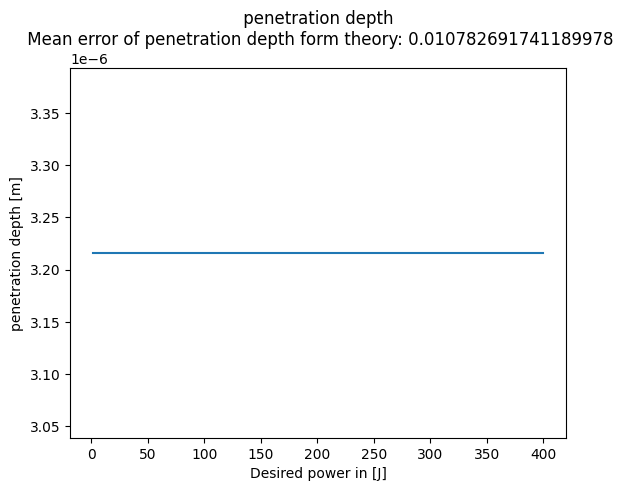

In [6]:
energy_in = np.linspace(1, 400, 20)
S_comp = np.zeros(np.size(energy_in))
transmition_vec = np.zeros(np.size(energy_in))
return_vec = np.zeros(np.size(energy_in))
penetration_vec = np.zeros(np.size(energy_in))

for i, E in enumerate(energy_in):
    
        
    time_res, spece_res = sim.simulation(z_list eps_r , sigma, alpha, ms0,
        E, fea , pulse_width,
        save_location, save_time, False,
        dt, simulation_time, lamda )

    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))
    
    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,-1,2] 

    S_send_to_void = sum(S_in_enter_point[:t1])*dt
    S_first_return_to_void = sum(S_in_enter_point[t1:t2_5])*dt
    S_first_enter_to_matirial = sum(S_in_z1[:t2])*dt

    S_depletion = S[:,1:-1,2]
    P_depletion = np.sum(S_depletion,0)* dt
    target = max(P_depletion)/np.e
    closest_index = np.argmin(np.abs(P_depletion - target)) 


    penetration_vec[i] = closest_index * dz
    S_comp[i] = S_send_to_void
    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = S_first_return_to_void/ S_send_to_void


check1_power_in=( (energy_in - S_comp)/energy_in)
plt.plot(energy_in, check1_power_in)
plt.xlabel("Desired power in [J]")
plt.title("Check 1: Difference between desired pulse power to actual pulse in space \n Send energy as power in ")
plt.ylabel("Relative mistake")
plt.show()


plt.plot(energy_in, transmition_vec)
plt.plot(energy_in, return_vec)
plt.legend(["transmition" ,  "return"])
plt.xlabel("Desired power in [J]")
plt.ylabel("Transmition and return Factors")
plt.title(f" Transmition and return Factors \n Mean error of reflection form theory: {np.mean(abs(return_vec)- theoretical_reflectivity)}")   

plt.show()

plt.plot(energy_in, penetration_vec)
plt.xlabel("Desired power in [J]")
plt.ylabel("penetration depth [m]")
plt.title(f" penetration depth \n Mean error of penetration depth form theory: {np.mean(theoretical_penetration_depth_p- penetration_vec) / theoretical_penetration_depth_p}")   
plt.show()


chack 2 - 
defrent polrizton 

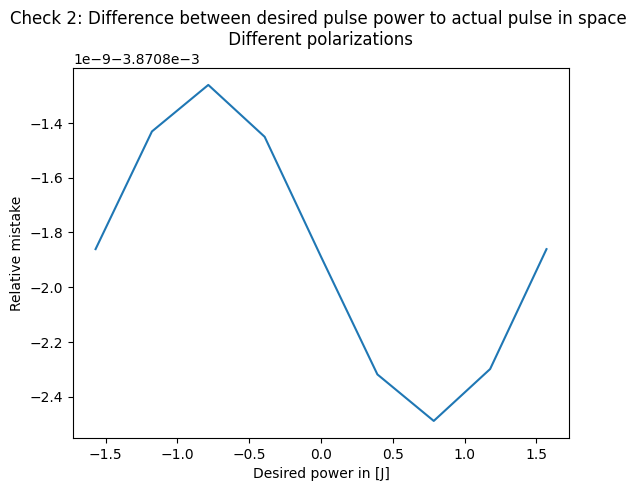

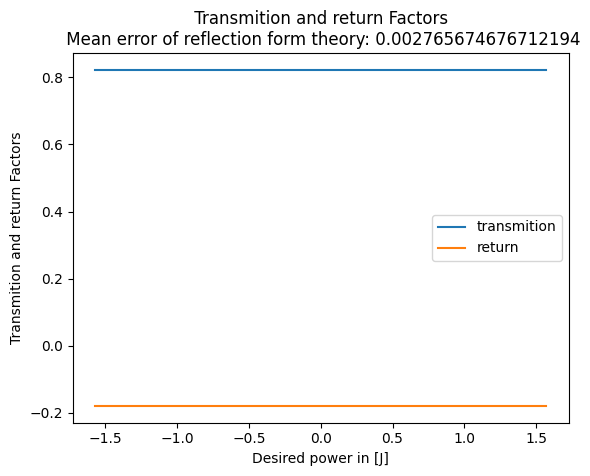

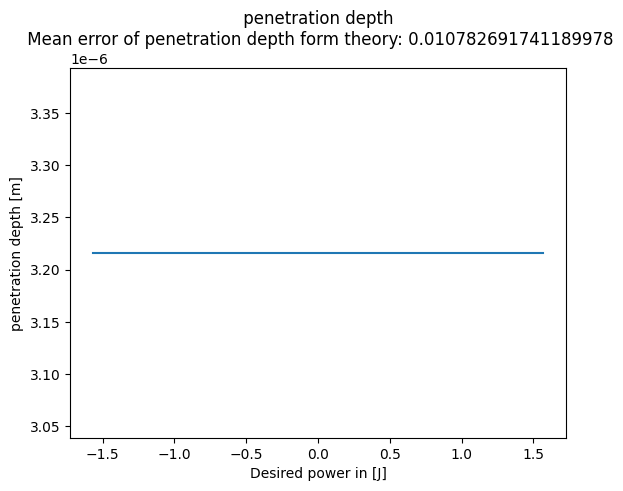

In [7]:
polariztion_vec = np.linspace(-np.pi/2, np.pi/2,9)
S_comp = np.zeros(np.size(polariztion_vec))
transmition_vec = np.zeros(np.size(polariztion_vec))
return_vec = np.zeros(np.size(polariztion_vec))
penetration_vec = np.zeros(np.size(polariztion_vec))

for i, few_i in enumerate(polariztion_vec):
    
        
    time_res, spece_res = sim.simulation(z1, z2, eps_r , sigma, alpha, ms0,
        power_in , few_i , pulse_width,
        save_location, save_time, False,
        dt, simulation_time, lamda )

    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))
    
    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,-1,2] 

    S_send_to_void = sum(S_in_enter_point[:t1])*dt
    S_first_return_to_void = sum(S_in_enter_point[t1:t2_5])*dt
    S_first_enter_to_matirial = sum(S_in_z1[:t2])*dt

    S_depletion = S[:,1:-1,2]
    P_depletion = np.sum(S_depletion,0)* dt
    target = max(P_depletion)/np.e
    closest_index = np.argmin(np.abs(P_depletion - target)) 


    penetration_vec[i] = closest_index * dz
    S_comp[i] = S_send_to_void
    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = S_first_return_to_void/ S_send_to_void


check2_power_in=( (power_in - S_comp)/power_in)
plt.plot(polariztion_vec, check2_power_in)
plt.title("Check 2: Difference between desired pulse power to actual pulse in space \n Different polarizations ")
plt.xlabel("Desired power in [J]")
plt.ylabel("Relative mistake")
plt.show()


plt.plot(polariztion_vec, transmition_vec)
plt.plot(polariztion_vec, return_vec)
plt.legend(["transmition" ,  "return"])
plt.xlabel("Desired power in [J]")
plt.ylabel("Transmition and return Factors")
plt.title(f" Transmition and return Factors \n Mean error of reflection form theory: {np.mean(abs(return_vec)- theoretical_reflectivity)}")   

plt.show()

plt.plot(polariztion_vec, penetration_vec)
plt.xlabel("Desired power in [J]")
plt.ylabel("penetration depth [m]")
plt.title(f" penetration depth \n Mean error of penetration depth form theory: {np.mean(theoretical_penetration_depth_p- penetration_vec) / theoretical_penetration_depth_p}")   
plt.show()


Chack 3 -
eps r change 

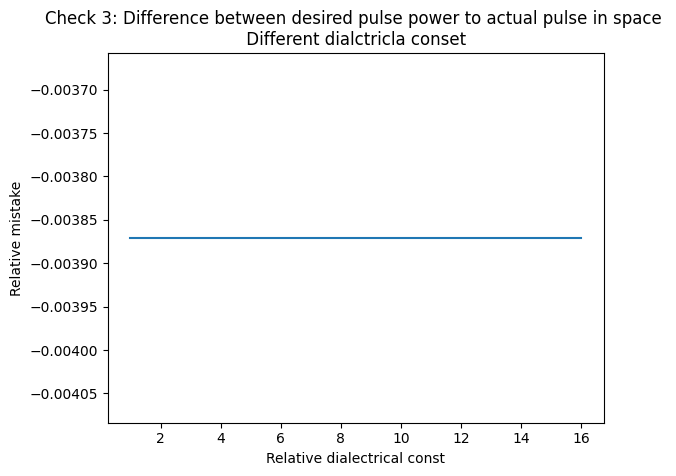

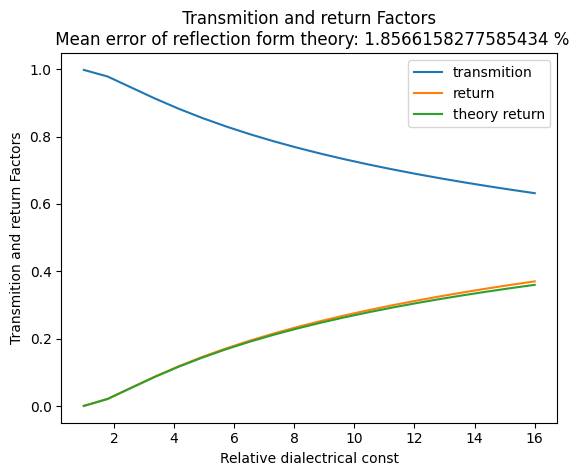

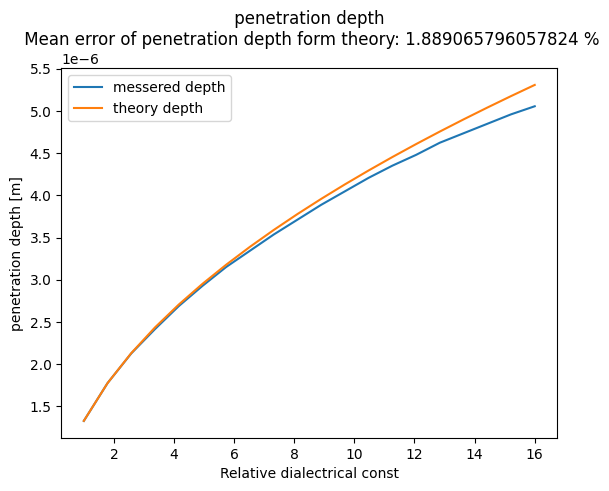

In [8]:
eps_r_vec = np.linspace(1,16, 20)
S_comp = np.zeros(np.size(eps_r_vec))
transmition_vec = np.zeros(np.size(eps_r_vec))
return_vec = np.zeros(np.size(eps_r_vec))
penetration_vec = np.zeros(np.size(eps_r_vec))

eps_r_comp_vec = eps_r_vec - 1j * sigma *lamda * sim.miu * sim.c /(2*np.pi)
n_vec = eps_r_comp_vec**0.5

theoretical_reflectivity_vec = (abs(( 1- n_vec) /(1 + n_vec))) ** 2
theoretical_transmision_vec = 1 - theoretical_reflectivity_vec
theoretical_penetration_e_vec = -1/ (2* np.pi/ lamda * np.imag(n_vec))  # power of the field decays to 1/e of its surface value.
theoretical_penetration_p_vec = 0.5 * theoretical_penetration_e_vec   # power decays to 1/e of its surface value.




for i, eps_r_i in enumerate(eps_r_vec):


    n_i = n_vec[i]

    len_matiral_i = int(8*pulse_width/dt/abs(n_i))*dz
    z2_i = z1 + int(len_matiral_i/dz) 
    lenz_i= z2_i + time_cut//2


    
    matiral_steps_i = int(2* abs(n_i)* (z2_i - z1))


    simulation_time_i = 2*(pik_enter_step + void_steps + matiral_steps_i + exit_steps)


    
    t3_i = t2 + 2*matiral_steps_i
    t2_5_i = (t2+ t3_i)//2


    save_location_i = np.arange(z1- 1,z2_i+1)
    save_location_i[0] = 4
    save_location_i[-1] = lenz_i- 6


    time_res, spece_res = sim.simulation(z1, z2_i, eps_r_i , sigma, alpha, ms0,
        power_in , fea , pulse_width,
        save_location_i, save_time, False,
        dt, simulation_time_i, lamda )

    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))
    
    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,-1,2] 

    S_send_to_void = sum(S_in_enter_point[:t1])*dt
    S_first_return_to_void = sum(S_in_enter_point[t1:t2_5_i])*dt
    S_first_enter_to_matirial = sum(S_in_z1[:t2])*dt

    S_depletion = S[:,1:-1,2]
    P_depletion = np.sum(S_depletion,0)* dt
    target = max(P_depletion)/np.e
    closest_index = np.argmin(np.abs(P_depletion - target)) 


    penetration_vec[i] = closest_index * dz
    S_comp[i] = S_send_to_void
    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = S_first_return_to_void/ S_send_to_void


check3_power_in=( (power_in - S_comp)/power_in)
plt.plot(eps_r_vec, check3_power_in)
plt.title("Check 3: Difference between desired pulse power to actual pulse in space \n Different dialctricla conset ")
plt.xlabel("Relative dialectrical const")
plt.ylabel("Relative mistake")
plt.show()


plt.plot(eps_r_vec, transmition_vec)
plt.plot(eps_r_vec, - return_vec)
plt.plot(eps_r_vec, theoretical_reflectivity_vec)
plt.legend(["transmition" ,  "return", "theory return"])
plt.xlabel("Relative dialectrical const")
plt.ylabel("Transmition and return Factors")
plt.title(f" Transmition and return Factors \n Mean error of reflection form theory: {100* np.mean((abs(return_vec)- theoretical_reflectivity_vec)/ theoretical_reflectivity_vec)} %")   

plt.show()

plt.plot(eps_r_vec, penetration_vec)
plt.plot(eps_r_vec, theoretical_penetration_p_vec)
plt.legend(["messered depth" ,  "theory depth"])
plt.xlabel("Relative dialectrical const")
plt.ylabel("penetration depth [m]")
plt.title(f" penetration depth \n Mean error of penetration depth form theory: {100* np.mean((theoretical_penetration_p_vec- penetration_vec) / theoretical_penetration_p_vec)} %")   
plt.show()






Check 4 -
condactivty chang 

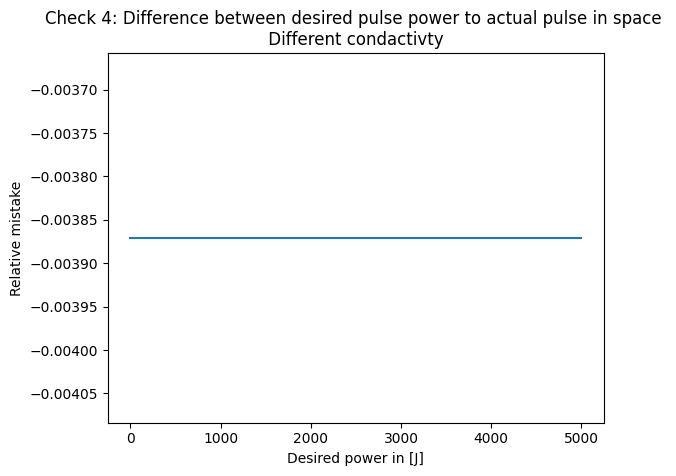

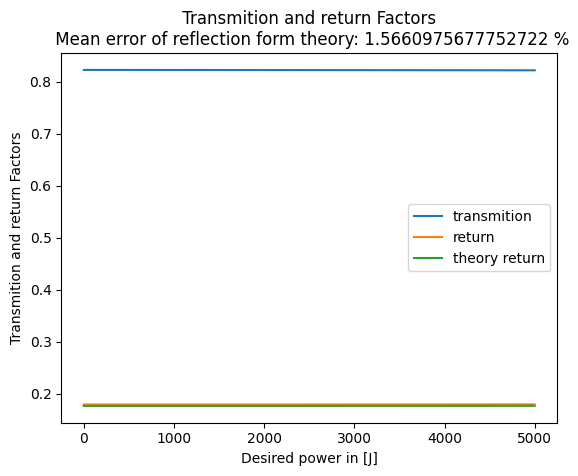

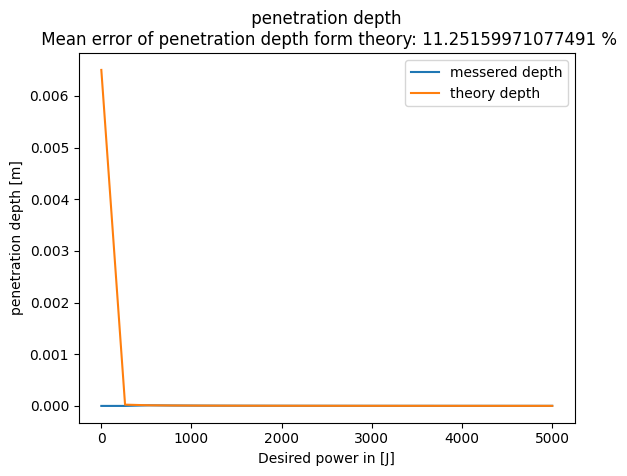

In [9]:
sigma_vec = np.linspace(1,5000, 20)
S_comp = np.zeros(np.size(sigma_vec))
transmition_vec = np.zeros(np.size(sigma_vec))
return_vec = np.zeros(np.size(sigma_vec))
penetration_vec = np.zeros(np.size(sigma_vec))

eps_r_comp_vec = eps_r - 1j * sigma_vec *lamda * sim.miu * sim.c /(2*np.pi)
n_vec = eps_r_comp_vec**0.5

theoretical_reflectivity_vec = (abs(( 1- n_vec) /(1 + n_vec))) ** 2
theoretical_transmision_vec = 1 - theoretical_reflectivity_vec
theoretical_penetration_e_vec = -1/ (2* np.pi/ lamda * np.imag(n_vec))  # power of the field decays to 1/e of its surface value.
theoretical_penetration_p_vec = 0.5 * theoretical_penetration_e_vec   # power decays to 1/e of its surface value.




for i, sigma_i in enumerate(sigma_vec):


    n_i = n_vec[i]

    len_matiral_i = int(8*pulse_width/dt/abs(n_i))*dz
    z2_i = z1 + int(len_matiral_i/dz) 
    lenz_i= z2_i + time_cut//2


    
    matiral_steps_i = int(2* abs(n_i)* (z2_i - z1))


    simulation_time_i = 2*(pik_enter_step + void_steps + matiral_steps_i + exit_steps)


    
    t3_i = t2 + 2*matiral_steps_i
    t2_5_i = (t2+ t3_i)//2


    save_location_i = np.arange(z1- 1,z2_i+1)
    save_location_i[0] = 4
    save_location_i[-1] = lenz_i- 6


    time_res, spece_res = sim.simulation(z1, z2_i, eps_r , sigma_i, alpha, ms0,
        power_in , fea , pulse_width,
        save_location_i, save_time, False,
        dt, simulation_time_i, lamda )

    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))
    
    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,-1,2] 

    S_send_to_void = sum(S_in_enter_point[:t1])*dt
    S_first_return_to_void = sum(S_in_enter_point[t1:t2_5_i])*dt
    S_first_enter_to_matirial = sum(S_in_z1[:t2])*dt
    if theoretical_penetration_p_vec[i] <len_matiral_i:
        S_depletion = S[:,1:-1,2]
        P_depletion = np.sum(S_depletion,0)* dt
        target = max(P_depletion)/np.e
        closest_index = np.argmin(np.abs(P_depletion - target)) 


        penetration_vec[i] = closest_index * dz
        
    S_comp[i] = S_send_to_void
    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = S_first_return_to_void/ S_send_to_void


check4_power_in=( (power_in - S_comp)/power_in)

plt.plot(sigma_vec, check4_power_in)
plt.title("Check 4: Difference between desired pulse power to actual pulse in space \n Different condactivty ")
plt.xlabel("condactivty [S/m^3]")
plt.ylabel("Relative mistake")
plt.show()


plt.plot(sigma_vec, transmition_vec)
plt.plot(sigma_vec, -return_vec)
plt.plot(sigma_vec, theoretical_reflectivity_vec)
plt.legend(["transmition" ,  "return", "theory return"])
plt.xlabel("condactivty [S/m^3]")
plt.ylabel("Transmition and return Factors")
plt.title(f" Transmition and return Factors \n Mean error of reflection form theory: {100* np.mean((abs(return_vec)- theoretical_reflectivity_vec)/ theoretical_reflectivity_vec)} %")   

plt.show()

plt.plot(sigma_vec, penetration_vec)
plt.plot(sigma_vec, theoretical_penetration_p_vec)
plt.legend(["messered depth" ,  "theory depth"])
plt.xlabel("condactivty [S/m^3]")
plt.ylabel("penetration depth [m]")
plt.title(f" penetration depth \n Mean error of penetration depth form theory: {100* np.mean((theoretical_penetration_p_vec- penetration_vec) / theoretical_penetration_p_vec)} %")   
plt.show()






check 5:
Pulse width effect on the energy in and Transmision and Return factors.

In [5]:
pulse_width_vec = np.linspace(0.5, 21 , 20) * time_cycal

S_comp = np.zeros(np.size(pulse_width_vec))
transmition_vec = np.zeros(np.size(pulse_width_vec))
return_vec = np.zeros(np.size(pulse_width_vec))
penetration_vec = np.zeros(np.size(pulse_width_vec))
ind_to_seve = int(2*theoretical_penetration_depth_p//dz)



for i, width in enumerate(pulse_width_vec):


    len_matiral_i = min(int(4*width/dt/abs(n))*dz, 2*ind_to_seve*dz)

    z1_i = int(3*width/dt) +3
    z2_i = z1_i + int(len_matiral_i/dz) 
    lenz_i= z2_i + time_cut//2


    pik_enter_step_i = 4*int(width/dt)
    void_steps_i = 2*z1_i
    matiral_steps_i = int(2* abs(n)* (z2_i - z1_i))


    simulation_time_i = 2*(pik_enter_step_i + void_steps_i + matiral_steps_i + exit_steps)


    t1_i = pik_enter_step_i + void_steps_i
    t2_i = t1_i + void_steps_i
    t3_i = t2_i + 2*matiral_steps_i
    t2_5_i = (t2_i + t3_i)//2

    
    save_location_i = np.arange(z1_i- 1 ,z1_i + len_matiral_i//dz)
    save_location_i[0] = 4
    save_location_i[-1] = lenz_i- 6


    time_res, spece_res = sim.simulation(z1_i, z2_i, eps_r , sigma, alpha, ms0,
        power_in , fea , width,
        save_location_i, save_time, False,
        dt, simulation_time_i, lamda )

    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))
    
    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,-1,2] 

    S_send_to_void = sum(S_in_enter_point[:t1_i])*dt
    S_first_return_to_void = sum(S_in_enter_point[t1_i:t2_5_i])*dt
    S_first_enter_to_matirial = sum(S_in_z1[:t2_i])*dt

    S_depletion = S[:,1:-1,2]
    P_depletion = np.sum(S_depletion,0)* dt
    target = max(P_depletion)/np.e
    closest_index = np.argmin(np.abs(P_depletion - target)) 


    penetration_vec[i] = closest_index * dz
    S_comp[i] = S_send_to_void
    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = S_first_return_to_void/ S_send_to_void

check5_power_in=( (power_in - S_comp)/power_in)


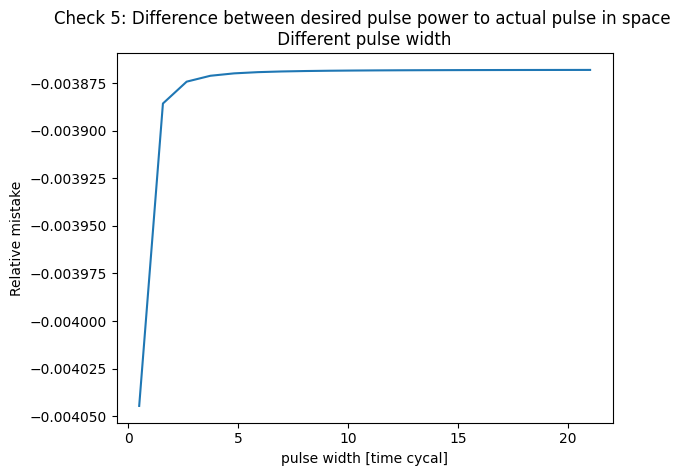

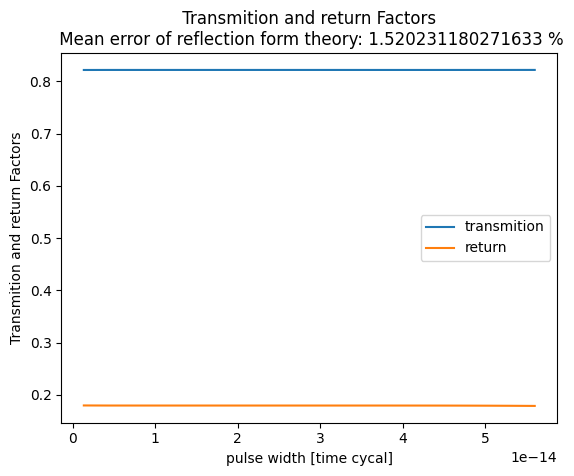

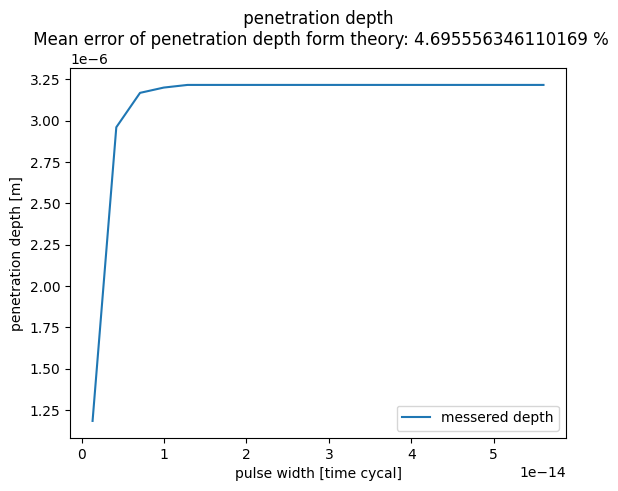

In [6]:


plt.plot(pulse_width_vec/ time_cycal, check5_power_in)
plt.title("Check 5: Difference between desired pulse power to actual pulse in space \n Different pulse width ")
plt.xlabel("pulse width [time cycal]")
plt.ylabel("Relative mistake")
plt.show()


plt.plot(pulse_width_vec, transmition_vec)
plt.plot(pulse_width_vec, -return_vec)
plt.legend(["transmition" ,  "return"])
plt.xlabel("pulse width [time cycal]")
plt.ylabel("Transmition and return Factors")
plt.title(f" Transmition and return Factors \n Mean error of reflection form theory: {100* np.mean((abs(return_vec)- theoretical_reflectivity)/ theoretical_reflectivity)} %")   

plt.show()

plt.plot(pulse_width_vec, penetration_vec)
plt.legend(["messered depth" ])
plt.xlabel("pulse width [time cycal]")
plt.ylabel("penetration depth [m]")
plt.title(f" penetration depth \n Mean error of penetration depth form theory: {100* np.mean((theoretical_penetration_depth_p- penetration_vec) / theoretical_penetration_depth_p)} %")   
plt.show()



Chakc 6:
time cut

In [30]:
time_cut_vec = np.arange(40, 281, 40)
dt_vec = time_cycal*np.logspace(-2.4, -1, 12)

S_comp = np.zeros(np.size(dt_vec))
transmition_vec = np.zeros(np.size(dt_vec))
return_vec = np.zeros(np.size(dt_vec))
penetration_vec = np.zeros(np.size(dt_vec))

depth_to_save = 2*theoretical_penetration_depth_p


for i, dt_i in enumerate(dt_vec):

    dz_i = 2*sim.c *dt_i


    len_matiral_i = int(4*pulse_width/dt_i/abs(n))*dz_i

    z1_i = int(3*pulse_width/dt_i) +3
    z2_i = z1_i + int(len_matiral_i/dz_i)
    cut = time_cycal/dt_i 
    lenz_i= z2_i + cut//2


    pik_enter_step_i = 4*int(pulse_width/dt_i)
    void_steps_i = 2*z1_i
    matiral_steps_i = int(2* abs(n)* (z2_i - z1_i))
    exit_steps_i = cut

    simulation_time_i = int(2*(pik_enter_step_i + void_steps_i + matiral_steps_i + exit_steps_i))


    t1_i = int(pik_enter_step_i + void_steps_i)
    t2_i = t1_i + void_steps_i
    t3_i = t2_i + 2*matiral_steps_i
    t2_5_i = int((t2_i + t3_i)//2)

    ind_to_seve_i = min(int(depth_to_save/dz_i), len_matiral_i//dz_i)

    save_location_i = np.arange(z1_i- 1,z1_i + ind_to_seve_i)
    save_location_i[0] = 4
    save_location_i[-1] = lenz_i- 6


    data = sim.simulation([z1_i ,z2_i], eps_r , sigma, alpha, ms0,
        power_in , fea , pulse_width,
        save_location_i, save_time, False,
        dt_i, simulation_time_i, lamda, time_interval= 1 )

    E_file= data["E in locations"]

    E = np.zeros((np.size(E_file, 0), np.size(E_file,1), 3)) # (time, loction, dimantion)
    H = np.zeros((np.size(E_file, 0), np.size(E_file,1), 3)) # (time, loction, dimantion)

    E[:,:,0:2] = sim.heta* np. real(E_file)
    H[:,:,0:2] = np.real(data["H in locations"])

    S = np.cross(np.real(E),np.real(H))

    S_in_enter_point = S[:,0,2]
    S_in_z1 = S[:,1,2]
    S_in_out = S[:,-1,2] 

    S_send_to_void = sum(S_in_enter_point[:t1_i])*dt_i
    S_first_return_to_void = sum(S_in_enter_point[t1_i:t2_5_i])*dt_i
    S_first_enter_to_matirial = sum(S_in_z1[:t2_i])*dt_i

    S_depletion = S[:,1:-1,2]
    P_depletion = np.sum(S_depletion,0)* dt_i
    target = max(P_depletion)/np.e
    closest_index = np.argmin(np.abs(P_depletion - target)) 


    penetration_vec[i] = closest_index * dz_i
    S_comp[i] = S_send_to_void
    transmition_vec[i] = S_first_enter_to_matirial/ S_send_to_void
    return_vec[i] = S_first_return_to_void/ S_send_to_void

check6_power_in=( (power_in - S_comp)/power_in)
d = {"penetration_vec" : penetration_vec, "theoretical_penetration_depth":theoretical_penetration_depth_p,
     "power_sent" : S_comp , "power_in": power_in,
     "transmition_masuer" : transmition_vec, "theoretical_transmision" : theoretical_transmision,
     "return_masuer" : return_vec, "theoretical_reflectivity" : theoretical_reflectivity,
     "dt_vec" : dt_vec ,"time_cycal": time_cycal}

simulation pross: 100%|██████████| 1456/1456 [00:00<00:00, 2654.06it/s]


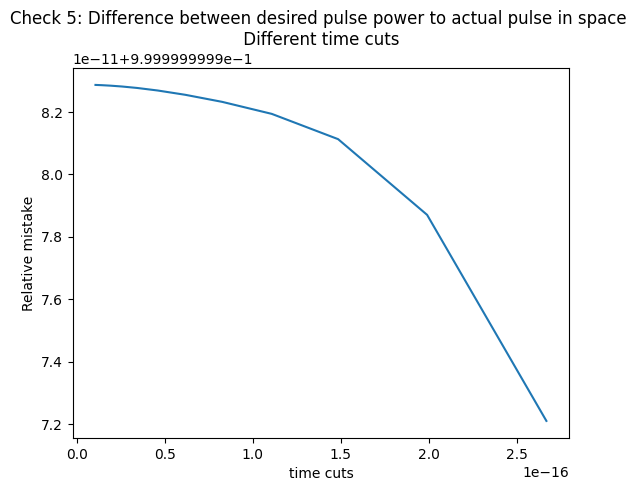

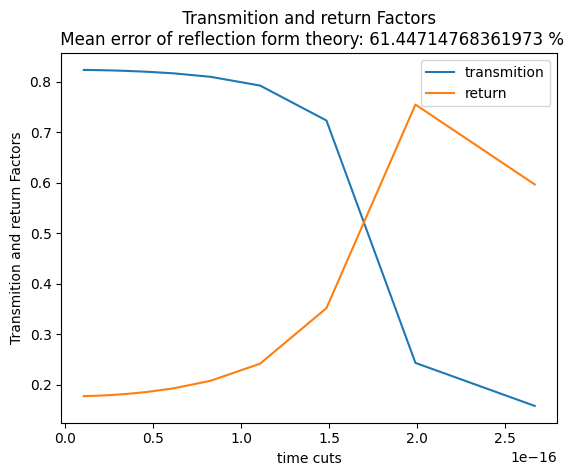

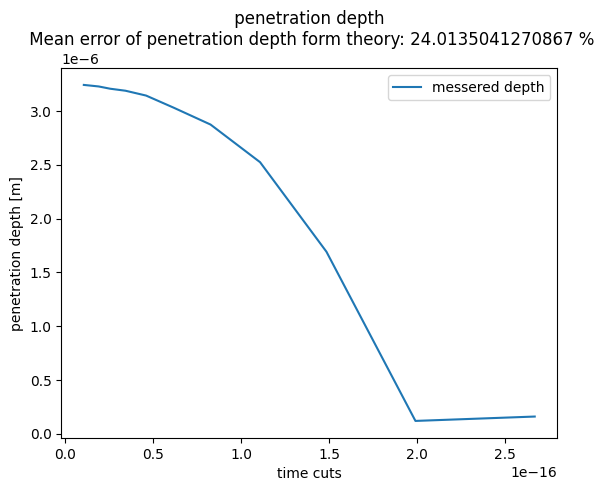

: 

In [ ]:

path = "C:\maxwell-LLG\ws\simulation_result\\"
np.save(path+ "cnodactivity_verf.npy", d)
plt.plot(dt_vec, check6_power_in)
plt.title("Check 5: Difference between desired pulse power to actual pulse in space \n Different time cuts ")
plt.xlabel("time cuts")
plt.ylabel("Relative mistake")
plt.show()



plt.plot(dt_vec, transmition_vec)
plt.plot(dt_vec, -return_vec)
plt.legend(["transmition" ,  "return"])
plt.xlabel("time cuts")
plt.ylabel("Transmition and return Factors")
plt.title(f" Transmition and return Factors \n Mean error of reflection form theory: {100* np.mean((abs(return_vec)- theoretical_reflectivity)/ theoretical_reflectivity)} %")   

plt.show()

plt.plot(dt_vec, penetration_vec)
plt.legend(["messered depth" ])
plt.xlabel("time cuts")
plt.ylabel("penetration depth [m]")
plt.title(f" penetration depth \n Mean error of penetration depth form theory: {100* np.mean((theoretical_penetration_depth_p- penetration_vec) / theoretical_penetration_depth_p)} %")   
plt.show()
